# NDVI Interpolation Analysis

## Overview

Satellite-derived NDVI time series frequently contain missing observations due to cloud cover, atmospheric contamination, sensor limitations, and irregular revisit intervals. These missing observations interrupt the vegetation signal and complicate subsequent analyses such as phenology detection, anomaly monitoring, and crop growth assessment.

Interpolation attempts to reconstruct the missing observations from the available data. However, every interpolation method introduces uncertainty, and its performance depends on both the interpolation algorithm and the size of the missing gap.

In this notebook, missing observations are **artificially removed** from a complete NDVI time series and reconstructed using several interpolation methods. Because the original values are known, the reconstruction error can be measured directly.

This notebook evaluates how interpolation accuracy changes as the amount of missing information increases.

## Import Libraries

In [36]:
import pandas as pd
import numpy as np
import sys

import matplotlib.pyplot as plt

from scipy.interpolate import CubicSpline

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import random

## Load Dataset

In [37]:
df = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/04_Phase_2_Time_Series/Layer B_Signal Behavior/dataset/ndvi_timeseries.csv")

## Routine Work

In [38]:
# Convert date column
sys.path.append('/content/drive/MyDrive/Agri_RS_AI_Project')
from src.time_processing import prepare_time_index

df = prepare_time_index(df)

# Droping extra column
df = df.drop(
    columns=['system:index', '.geo'],
    errors='ignore'
    )


# Remove duplicate
duplicates = df.index.duplicated().sum()
df = df[~df.index.duplicated(keep="first")]

# Why Artificially Remove Observations?

Real missing observations are caused by factors such as:

- Cloud cover
- Heavy rainfall
- Atmospheric contamination
- Cloud masking
- Sensor revisit limitations

When observations are already missing, the true NDVI values are unknown. As a result, interpolation accuracy cannot be measured directly.

To evaluate interpolation objectively, this notebook begins with a complete NDVI time series and **artificially removes observations**. The removed values become the **ground truth**, allowing reconstructed values to be compared against the original measurements.

This approach transforms interpolation into a supervised reconstruction problem, where prediction error can be quantified.

## Experimental Workflow

```text
Original NDVI Time Series
          │
          ▼
Artificially Remove Observations
          │
          ▼
Incomplete NDVI Time Series
          │
          ▼
Apply Interpolation Methods
          │
          ▼
Reconstructed NDVI Time Series
          │
          ▼
Compare with Original Values
          │
          ▼
Calculate RMSE, MAE, and R²
```

## Define Evaluation Metrics

In [39]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)


def r2(y_true, y_pred):
    return r2_score(y_true, y_pred)

## Create a Working Copy

In [40]:
analysis_df = df.copy()

## Random Missing Data & Interpolation

### Set Experiment Parameters

In [41]:
# Percentage of observations to remove
missing_fraction = 0.30

# Random seed for reproducibility
random_state = 42

In [42]:
np.random.seed(random_state)

interp_df = analysis_df.copy()

# Number of observations to remove
n_remove = int(len(interp_df) * missing_fraction)

# Random indices
missing_idx = np.random.choice(
    interp_df.index,
    size=n_remove,
    replace=False # Don't pick the same date twice.
)

# Store original values (Ground Truth)

ground_truth = interp_df.loc[missing_idx].copy()

# Remove observations

interp_df.loc[missing_idx, "NDVI"] = np.nan

print(f"Removed observations : {n_remove}")

display(ground_truth.head())

Removed observations : 20


,NDVI
date,
2023-12-30,0.378959
2023-01-09,0.533609
2025-02-27,0.358346
2023-02-13,0.481330
2025-03-29,0.655799


## Visualize Missing Observations

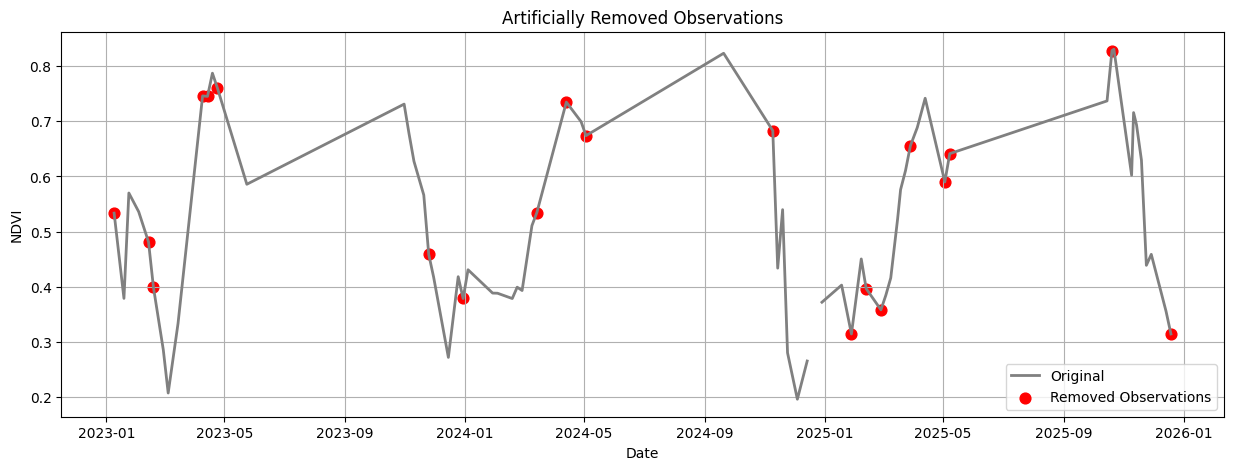

In [43]:
plt.figure(figsize=(15,5))

plt.plot(
    analysis_df.index,
    analysis_df["NDVI"],
    color="gray",
    linewidth=2,
    label="Original"
)

plt.scatter(
    ground_truth.index,
    ground_truth["NDVI"],
    color="red",
    s=60,
    label="Removed Observations"
)

plt.title("Artificially Removed Observations")

plt.xlabel("Date")

plt.ylabel("NDVI")

plt.grid(True)

plt.legend()

plt.show()

## Linear Interpolation

In [44]:
linear_df = interp_df.copy()

linear_df["NDVI"] = (
    interp_df["NDVI"]
    .interpolate(
        method="linear",
        limit_direction="both" # Interpolate first and last value
    )
)

# Nearest Neighbor Interpolation

In [45]:
nearest_df = interp_df.copy()

nearest_df["NDVI"] = (
    interp_df["NDVI"]
    .interpolate(
        method="nearest",
        limit_direction="both"
    )
)

## Cubic Spline Interpolation

In [46]:
spline_df = interp_df.copy()

spline_df["NDVI"] = (
    interp_df["NDVI"]
    .interpolate(
        method="spline",
        order=3,
        limit_direction="both"
    )
)

## Compare All Interpolation Methods

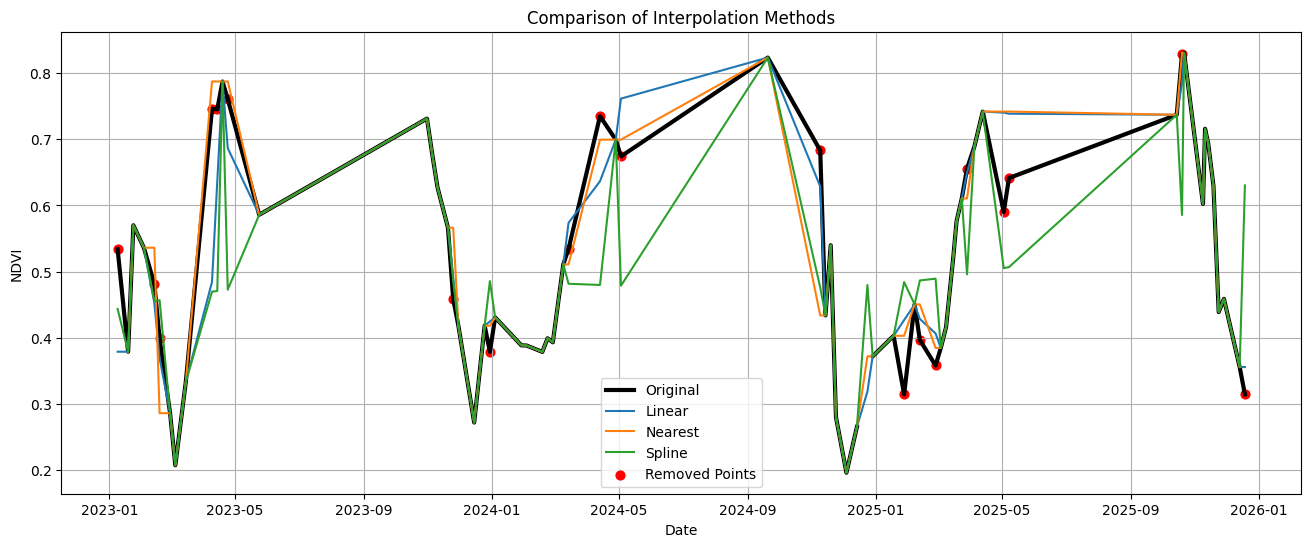

In [47]:
plt.figure(figsize=(16,6))

plt.plot(
    analysis_df.index,
    analysis_df["NDVI"],
    color="black",
    linewidth=3,
    label="Original"
)

plt.plot(
    linear_df.index,
    linear_df["NDVI"],
    label="Linear"
)

plt.plot(
    nearest_df.index,
    nearest_df["NDVI"],
    label="Nearest"
)

plt.plot(
    spline_df.index,
    spline_df["NDVI"],
    label="Spline"
)

plt.scatter(
    ground_truth.index,
    ground_truth["NDVI"],
    color="red",
    s=40,
    label="Removed Points"
)

plt.title("Comparison of Interpolation Methods")

plt.xlabel("Date")

plt.ylabel("NDVI")

plt.grid(True)

plt.legend()

plt.show()

## Observations

The interpolation methods successfully reconstructed a continuous NDVI time series from the incomplete observations.

Visual differences among the methods are apparent:

- **Linear interpolation** connects neighboring observations using straight-line segments.
- **Nearest Neighbor interpolation** creates step-like transitions by assigning the closest observed value.
- **Cubic Spline interpolation** generates a smooth continuous curve that follows the overall vegetation trend.

In the next section, these reconstructed values will be quantitatively compared with the original observations using RMSE, MAE, and R².

## Reconstruction Accuracy Assessment

## Extract Predicted Values

In [48]:
# Predicted values only at removed locations

linear_pred = linear_df.loc[ground_truth.index, "NDVI"]

nearest_pred = nearest_df.loc[ground_truth.index, "NDVI"]

spline_pred = spline_df.loc[ground_truth.index, "NDVI"]

true_values = ground_truth["NDVI"]

##

In [49]:
comparison = pd.DataFrame({
    "True": analysis_df["NDVI"],
    "Linear": linear_df["NDVI"],
    "Nearest": nearest_df["NDVI"],
    "Spline": spline_df["NDVI"]
})
comparison = comparison.dropna()

comparison.head()

,True,Linear,Nearest,Spline
date,,,,
2023-01-19,0.379122,0.379122,0.379122,0.379122
2023-01-24,0.570066,0.570066,0.570066,0.570066
2023-02-03,0.536162,0.536162,0.536162,0.536162
2023-02-13,0.481330,0.452859,0.536162,0.455518
2023-02-18,0.399204,0.369556,0.286252,0.457028


## Calculate Evaluation Metrics

In [51]:
results = []

for method in ["Linear", "Nearest", "Spline"]:

    results.append({

        "Method": method,

        "RMSE": rmse(comparison["True"], comparison[method]),

        "MAE": mae(comparison["True"], comparison[method]),

        "R²": r2(comparison["True"], comparison[method])

    })

results = pd.DataFrame(results)

results = results.round(4)

results

,Method,RMSE,MAE,R²
0,Linear,0.0496,0.0205,0.9118
1,Nearest,0.0467,0.0186,0.9217
2,Spline,0.0924,0.0421,0.6942


## Interpretation

The quantitative evaluation provides an objective comparison of interpolation performance.

General interpretation:

- Lower **RMSE** indicates smaller reconstruction errors.
- Lower **MAE** indicates better average prediction accuracy.
- Higher **R²** indicates stronger agreement between reconstructed and original NDVI observations.

The best-performing interpolation method will be used as the reference for the gap-length sensitivity analysis in the next section.